<a href="https://colab.research.google.com/github/Keerthanatamma/nasscom/blob/main/day_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving heart+disease.zip to heart+disease.zip


In [ ]:
import zipfile

with zipfile.ZipFile("heart+disease.zip", "r") as zip_ref:
    zip_ref.extractall("heart_dataset")

In [ ]:
import os

print(os.listdir("heart_dataset"))

['costs', 'Index', 'processed.switzerland.data', 'ask-detrano', 'reprocessed.hungarian.data', 'long-beach-va.data', 'WARNING', 'hungarian.data', 'switzerland.data', 'processed.cleveland.data', 'bak', 'cleve.mod', 'heart-disease.names', 'new.data', 'processed.va.data', 'processed.hungarian.data', 'cleveland.data']


In [ ]:
import pandas as pd

df = pd.read_csv("heart_dataset/processed.cleveland.data",header=None)

df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
columns = [
    'age','sex','cp','trestbps','chol',
    'fbs','restecg','thalach','exang',
    'oldpeak','slope','ca','thal','target'
]

df.columns = columns

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
df.to_csv("heart_disease.csv", index=False)

In [ ]:
# Core imports for the whole lab
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
print('Setup complete. pandas', pd.__version__)


# -----------------------------------------------------------
# A SMALL, ALREADY-CLEAN DATASET (Part 1 did the cleaning)
# -----------------------------------------------------------
# Mixed columns: an unordered category (city), an ordered category
# (size), two numeric features on very different scales, and a target.
df = pd.DataFrame({
    'city':   ['pune', 'delhi', 'mumbai', 'pune', 'delhi', 'mumbai', 'pune', 'delhi'],
    'size':   ['small', 'large', 'medium', 'medium', 'small', 'large', 'large', 'small'],
    'age':    [25, 41, 33, 29, 52, 38, 46, 22],
    'income': [38000, 92000, 55000, 47000, 120000, 76000, 88000, 41000],
    'bought': [0, 1, 0, 0, 1, 1, 1, 0],   # target
})
df



Setup complete. pandas 2.2.2


,city,size,age,income,bought
0,pune,small,25,38000,0
1,delhi,large,41,92000,1
2,mumbai,medium,33,55000,0
3,pune,medium,29,47000,0
4,delhi,small,52,120000,1
5,mumbai,large,38,76000,1
6,pune,large,46,88000,1
7,delhi,small,22,41000,0


In [ ]:
# -----------------------------------------------------------
# 🔹 1A. ONE-HOT ENCODING (for UNORDERED categories)
# -----------------------------------------------------------

# 'city' has no natural order -> one 0/1 column per category
city_ohe = pd.get_dummies(df['city'], prefix='city').astype(int)
city_ohe


# -----------------------------------------------------------
# 🔹 1B. LABEL / ORDINAL ENCODING (for ORDERED categories)
# -----------------------------------------------------------

# 'size' has a real order: small < medium < large -> map to 0,1,2
size_order = {'small': 0, 'medium': 1, 'large': 2}
df['size_code'] = df['size'].map(size_order)
df[['size', 'size_code']]



In [ ]:
import pandas as pd

city_ohe = pd.get_dummies(df['city'], prefix='city').astype(int)

size_order = {'small': 0, 'medium': 1, 'large': 2}
df['size_code'] = df['size'].map(size_order)
df[['size', 'size_code']]

,size,size_code
0,small,0
1,large,2
2,medium,1
3,medium,1
4,small,0
5,large,2
6,large,2
7,small,0


In [ ]:
income = df[['income']]
from sklearn.preprocessing import StandardScaler, MinMaxScaler

z = StandardScaler().fit_transform(income)        # mean 0, std 1
m = MinMaxScaler().fit_transform(income)          # range [0, 1]

print('Standardised (mean~0, std~1):')
print(pd.DataFrame(z, columns=[ 'income']).round(2).head(3))
print('\nMin-Max (range 0..1):')
print(pd.DataFrame(m, columns=[ 'income']).round(2).head(3))

Standardised (mean~0, std~1):
   income
0   -1.16
1    0.82
2   -0.54

Min-Max (range 0..1):
   income
0    0.00
1    0.66
2    0.21
Standardised (mean~0, std~1):
   income
0   -1.16
1    0.82
2   -0.54

Min-Max (range 0..1):
   income
0    0.00
1    0.66
2    0.21


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Redefine df here to ensure it's available in this cell
df = pd.DataFrame({
    'city':   ['pune', 'delhi', 'mumbai', 'pune', 'delhi', 'mumbai', 'pune', 'delhi'],
    'size':   ['small', 'large', 'medium', 'medium', 'small', 'large', 'large', 'small'],
    'age':    [25, 41, 33, 29, 52, 38, 46, 22],
    'income': [38000, 92000, 55000, 47000, 120000, 76000, 88000, 41000],
    'bought': [0, 1, 0, 0, 1, 1, 1, 0],   # target
})

# Define X as features (e.g., 'age' and 'income' from df)
X = df[['age', 'income']]

# Split data into training and test sets
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

# 1a. WRONG: fit on ALL data, then split (leakage!)
wrong_mean = StandardScaler().fit(X).mean_

# 1b. RIGHT: fit on TRAIN only
right_mean = StandardScaler().fit(X_train).mean_

print('fit-on-all mean :', wrong_mean.round(1))
print('fit-on-train mean:', right_mean.round(1))

fit-on-all mean : [3.5800e+01 6.9625e+04]
fit-on-train mean: [3.45000e+01 6.48333e+04]


In [ ]:
import pandas as pd

ex = df.copy()

# 1. high_earner flag (income > median)
median_income = ex['income'].median()
ex['high_earner'] = ex['income'] > median_income

# 2. bin income into 3 buckets
ex['income_group'] = pd.cut(
    ex['income'],
    bins=3,
    labels=['low', 'mid', 'high']
)

# 3. show income + the new columns
print(ex[['income', 'high_earner', 'income_group']])

   income  high_earner income_group
0   38000        False          low
1   92000         True          mid
2   55000        False          low
3   47000        False          low
4  120000         True         high
5   76000         True          mid
6   88000         True          mid
7   41000        False          low


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression

Xn = df[['age', 'income']]
yn = df['bought']

# 1. Pipeline: MinMaxScaler -> LogisticRegression
pipe_num = Pipeline([
    ('scaler', MinMaxScaler()),
    ('model', LogisticRegression())
])

# 2. Split + Fit on train
X_train, X_test, y_train, y_test = train_test_split(
    Xn, yn, test_size=0.25, random_state=0
)

pipe_num.fit(X_train, y_train)

# 3. Print test accuracy
acc = pipe_num.score(X_test, y_test)
print("Test Accuracy:", round(acc, 2))

Test Accuracy: 1.0


In [ ]:


# === SETUP: load the provided data files (regenerate them if missing) ===
import os
import numpy as np
import pandas as pd

def build_datasets(csv_path='ecommerce_customers.csv',
                   xlsx_path='transactions.xlsx', seed=42, verbose=False):
    """Generate a realistic e-commerce customer + transactions dataset.

    Baked-in realism for EDA / feature engineering practice:
      - right-skewed monetary columns (total_spend) with a few 'whale' outliers
      - class imbalance in is_churned (~20-30%)
      - real signal: churn depends on recency, order count and support tickets
      - missing values in age / gender / city
      - a high-cardinality 'city' column (long tail of rare cities)
      - customers with zero orders (no last_order_date) -> dormant
    The Excel file is order-level and is CONSISTENT with the customer table
    (num_orders / total_spend / last_order_date are derived from it).
    """
    rng = np.random.default_rng(seed)
    N = 2500
    start = pd.Timestamp('2021-01-01')
    end = pd.Timestamp('2024-06-30')
    horizon = (end - start).days

    cust = np.array([f'CUST{i+1:05d}' for i in range(N)])
    signup_off = rng.integers(0, horizon - 60, N)
    signup = start + pd.to_timedelta(signup_off, unit='D')

    # order counts: overdispersed (gamma-poisson), some customers have zero
    lam = rng.gamma(2.0, 1.6, N)
    num_orders = rng.poisson(lam)

    # ---- order-level transactions (vectorised) ----
    counts = num_orders
    tot = int(counts.sum())
    cust_rep = np.repeat(cust, counts)
    signup_rep = np.repeat(signup_off, counts)
    span = np.maximum(horizon - signup_off, 1)
    span_rep = np.repeat(span, counts)
    off = (rng.random(tot) * span_rep).astype(int)
    tx_off = signup_rep + off
    tx_date = start + pd.to_timedelta(tx_off, unit='D')
    amount = rng.lognormal(3.2, 0.8, tot).round(2)        # right-skewed (~tens of currency)
    category = rng.choice(['Electronics', 'Fashion', 'Grocery', 'Home', 'Books'],
                          tot, p=[.20, .30, .25, .15, .10])
    tx = pd.DataFrame({'customer_id': cust_rep, 'order_date': tx_date,
                       'amount': amount, 'category': category}).sort_values(
        ['customer_id', 'order_date']).reset_index(drop=True)

    # ---- aggregate transactions -> customer level ----
    agg = tx.groupby('customer_id').agg(
        total_spend=('amount', 'sum'),
        first_order=('order_date', 'min'),
        last_order=('order_date', 'max'),
    ).reset_index()

    df = pd.DataFrame({'customer_id': cust, 'signup_date': signup,
                       'num_orders': num_orders})
    df = df.merge(agg, on='customer_id', how='left')
    df['total_spend'] = df['total_spend'].fillna(0).round(2)

    # ---- demographics & account attributes ----
    df['age'] = np.clip(rng.normal(38, 12, N), 18, 82).round().astype(int)
    df['gender'] = rng.choice(['M', 'F', 'Other'], N, p=[.48, .48, .04])

    majors = ['Mumbai', 'Delhi', 'Bengaluru', 'Hyderabad', 'Chennai', 'Pune', 'Kolkata']
    rare = ['Jaipur', 'Surat', 'Indore', 'Bhopal', 'Patna', 'Nagpur',
            'Kochi', 'Coimbatore', 'Visakhapatnam', 'Lucknow']
    pool = majors + rare
    w = np.array([.17, .15, .14, .12, .10, .08, .06] + [.013] * 10)
    w = w / w.sum()
    df['city'] = rng.choice(pool, N, p=w)

    df['plan'] = rng.choice(['Basic', 'Standard', 'Premium'], N, p=[.50, .35, .15])
    df['device'] = rng.choice(['Mobile', 'Desktop', 'Tablet'], N, p=[.60, .32, .08])
    df['payment_method'] = rng.choice(['Card', 'UPI', 'Wallet', 'NetBanking'],
                                      N, p=[.40, .35, .15, .10])
    df['support_tickets'] = rng.poisson(0.6, N)
    df['email_opt_in'] = rng.choice([0, 1], N, p=[.35, .65])

    # ---- churn target with real signal (recency / orders / tickets) ----
    last = pd.to_datetime(df['last_order'])
    days_since = (end - last).dt.days
    days_since_filled = days_since.fillna(horizon).to_numpy()
    z = (-2.75
         + 0.0019 * days_since_filled
         + 0.30 * df['support_tickets'].to_numpy()
         - 0.05 * df['num_orders'].to_numpy()
         + 0.70 * (df['num_orders'].to_numpy() == 0))
    p = 1 / (1 + np.exp(-z))
    df['is_churned'] = (rng.random(N) < p).astype(int)

    # ---- format dates as ISO strings (NaT -> ) ----
    df = df.rename(columns={'first_order': 'first_order_date',
                            'last_order': 'last_order_date'})
    for c in ['signup_date', 'first_order_date', 'last_order_date']:
        df[c] = pd.to_datetime(df[c]).dt.date.astype('string')

    df = df[['customer_id', 'signup_date', 'first_order_date', 'last_order_date',
             'age', 'gender', 'city', 'plan', 'device', 'payment_method',
             'num_orders', 'total_spend', 'support_tickets', 'email_opt_in',
             'is_churned']]

    # ---- inject missing values AFTER computing the target ----
    def punch(col, frac):
        idx = rng.choice(N, int(frac * N), replace=False)
        df.loc[idx, col] = np.nan
    punch('age', 0.07)
    punch('gender', 0.04)
    punch('city', 0.02)

    # ---- write files ----
    df.to_csv(csv_path, index=False)
    tx_out = tx.copy()
    tx_out['order_date'] = pd.to_datetime(tx_out['order_date']).dt.date.astype('string')
    tx_out.to_excel(xlsx_path, index=False)

    if verbose:
        print('customers:', df.shape, '| transactions:', tx_out.shape)
        print('churn rate:', round(df["is_churned"].mean(), 3))
        print('total_spend skew:', round(df["total_spend"].skew(), 2))
        print('missing age:', int(df["age"].isna().sum()),
              '| missing city:', int(df["city"].isna().sum()))
        print('zero-order customers:', int((df["num_orders"] == 0).sum()))
        print('distinct cities:', df["city"].nunique())
    return df, tx_out

if not (os.path.exists('ecommerce_customers.csv') and os.path.exists('transactions.xlsx')):
    build_datasets()   # creates the two resource files locally
    print('Generated dataset files.')
else:
    print('Found the provided dataset files.')


# Load the customer table (parse the date columns as real datetimes)
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

df = pd.read_csv('ecommerce_customers.csv',
                 parse_dates=['signup_date', 'first_order_date', 'last_order_date'])
print('Loaded', df.shape[0], 'customers x', df.shape[1], 'columns')
df.head()



Generated dataset files.
Loaded 2500 customers x 15 columns


,customer_id,signup_date,first_order_date,last_order_date,age,gender,city,plan,device,payment_method,num_orders,total_spend,support_tickets,email_opt_in,is_churned
0,CUST00001,2021-04-19,NaT,NaT,31.0,F,Chennai,Premium,Desktop,Card,0,0.00,2,0,0
1,CUST00002,2023-07-31,NaT,NaT,54.0,F,Hyderabad,Standard,Desktop,Wallet,0,0.00,1,0,1
2,CUST00003,2023-03-07,2023-05-22,2023-05-22,43.0,Other,Pune,Premium,Mobile,Wallet,1,39.17,1,0,0
3,CUST00004,2022-06-18,2022-07-02,2022-07-02,28.0,F,Pune,Standard,Desktop,Card,1,2.74,1,1,0
4,CUST00005,2022-06-11,2022-09-18,2024-06-15,30.0,F,Mumbai,Standard,Mobile,Wallet,4,133.80,0,0,0


In [ ]:
print(df['customer_id'].is_unique)
print(df.describe)

True
<bound method NDFrame.describe of      customer_id signup_date first_order_date last_order_date   age gender  \
0      CUST00001  2021-04-19              NaT             NaT  31.0      F   
1      CUST00002  2023-07-31              NaT             NaT  54.0      F   
2      CUST00003  2023-03-07       2023-05-22      2023-05-22  43.0  Other   
3      CUST00004  2022-06-18       2022-07-02      2022-07-02  28.0      F   
4      CUST00005  2022-06-11       2022-09-18      2024-06-15  30.0      F   
...          ...         ...              ...             ...   ...    ...   
2495   CUST02496  2021-09-07       2022-06-27      2024-05-03  35.0      M   
2496   CUST02497  2023-09-02       2023-11-14      2023-11-14  25.0  Other   
2497   CUST02498  2023-12-17       2024-03-22      2024-03-22  23.0      M   
2498   CUST02499  2021-02-09              NaT             NaT  36.0      F   
2499   CUST02500  2024-02-05              NaT             NaT  21.0      M   

            city      pl

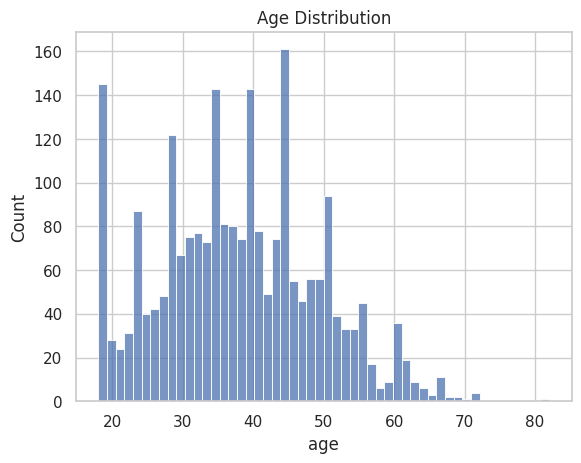

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

num_bins = 52

sns.histplot(df['age'].dropna(), bins=num_bins)

plt.title("Age Distribution")
plt.show()

In [ ]:
print("Orders Skew:",df['num_orders'].skew())

print("Spend Skew:", df['total_spend'].skew())

Orders Skew: 1.35301053502581
Spend Skew: 1.731732234873782


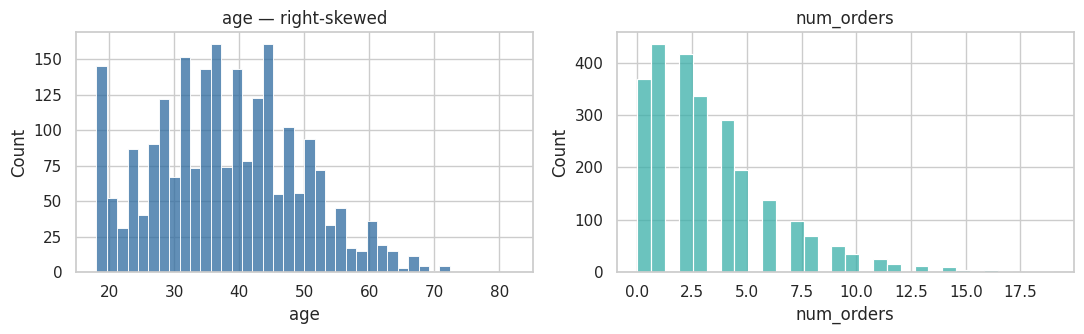

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(df['age'], bins=40, ax=ax[0], color='#2D6A9F')
ax[0].set_title('age — right-skewed')
sns.histplot(df['num_orders'], bins=30, ax=ax[1], color='#3AAFA9')
ax[1].set_title('num_orders')
plt.tight_layout(); plt.show()

is_churned
0    0.834
1    0.166
Name: proportion, dtype: float64
5.024096385542169


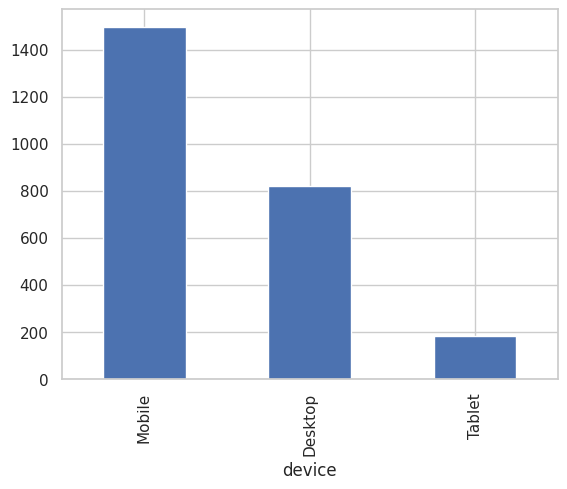

In [ ]:
print(df['is_churned'].value_counts(normalize=True))

retained = (df['is_churned']==0).sum()

churned = (df['is_churned']==1).sum()

ratio = retained/churned

print(ratio)

df['device'].value_counts().plot( kind='bar')

plt.show()

correlation: 0.007


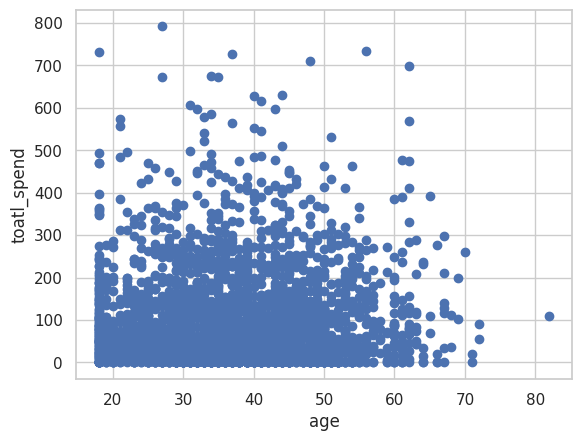

In [ ]:
plt.scatter(df['age'], df['total_spend'])
plt.xlabel('age')
plt.ylabel('toatl_spend')
print('correlation:',round(df['age'].corr(df['total_spend']), 3))